<a href="https://colab.research.google.com/github/zeynepbykn/SMS_Spam_Tespiti_Proje/blob/main/SMS_spam_veriBilimi_proje.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Veriyi Okuma ve İstatistikleri **Çıkarma**

In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import zipfile
import requests
import io

# 1. ADIM: Veriyi doğrudan UCI sitesinden indiriyoruz (Zeynep & Kübra Ortak)
url = "https://archive.ics.uci.edu/static/public/228/sms+spam+collection.zip"
response = requests.get(url)

# 2. ADIM: İndirilen zip içeriğini açıyoruz
with zipfile.ZipFile(io.BytesIO(response.content), 'r') as zip_ref:
    zip_ref.extractall('sms_data') # 'sms_data' isimli bir klasöre çıkartır


df = pd.read_csv('sms_data/SMSSpamCollection', sep='\t', names=['label', 'message'])

print("Veri Seti Boyutu:", df.shape) # (5574, 2):5574 mesaj ve 2 sütun
## df.head(): Tablonun en üstündeki ilk 5 satırı ekrana getirir,kontrol etmemizi sağlar.
print("\nİlk 5 Satır:\n", df.head())

# Sınıf Dağılımı
# label sütunundaki değerleri sayar:kaç tane ham,spam mesaj oldugu yazıyor.
print("\nSınıf Sayıları:")
print(df['label'].value_counts())

Veri Seti Boyutu: (5572, 2)

İlk 5 Satır:
   label                                            message
0   ham  Go until jurong point, crazy.. Available only ...
1   ham                      Ok lar... Joking wif u oni...
2  spam  Free entry in 2 a wkly comp to win FA Cup fina...
3   ham  U dun say so early hor... U c already then say...
4   ham  Nah I don't think he goes to usf, he lives aro...

Sınıf Sayıları:
label
ham     4825
spam     747
Name: count, dtype: int64


Görselleştirme (Grafik) **Kodları**

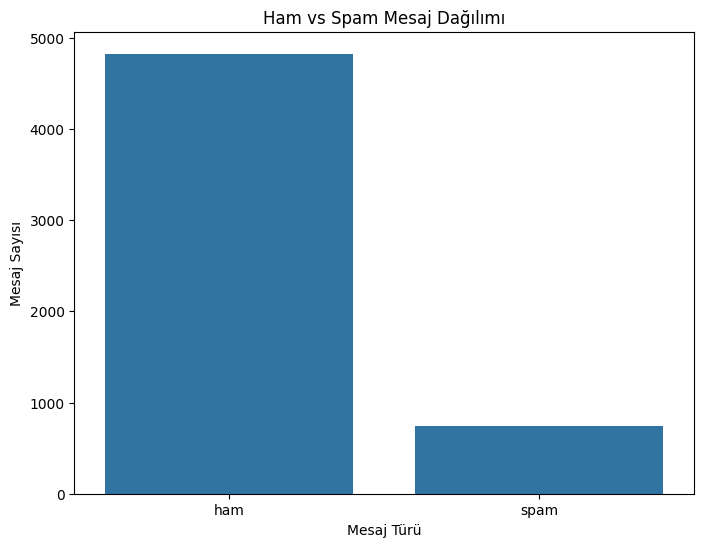

In [2]:
# Grafiğin boyutu: (8 birim genişlik, 6 birim yükseklik).
plt.figure(figsize=(8,6))

# sns.countplot: Kategorik veriler için (ham/spam) sütun grafiği çizer.
# x='label': Alt eksende etiketler (ham ve spam) yer alacak.
sns.countplot(x='label', data=df)

# Grafiğe başlık ve eksen isimleri ekliyoruz.
plt.title('Ham vs Spam Mesaj Dağılımı') # Grafiğin ana başlığı.
plt.xlabel('Mesaj Türü') # Yatay eksen ismi.
plt.ylabel('Mesaj Sayısı') # Dikey eksen ismi.

# plt.show ile grafiği çizer
plt.show()

# Veri Temizliği(NLP Preprocessing)

In [3]:
import string
import nltk
from nltk.corpus import stopwords

# Gerekli paketleri indiriyoruz
nltk.download('stopwords')
stop_words = set(stopwords.words('english'))

def temizle(metin):
    metin = metin.lower() # Hepsini kucuk harfe çevirir.
    metin = ''.join([char for char in metin if char not in string.punctuation]) # Noktalama işaretlerini kaldırır.
    metin = ''.join([char for char in metin if not char.isdigit()]) # Sayıları kaldırır.
    metin = ' '.join([kelime for kelime in metin.split() if kelime not in stop_words]) # Stopwords(the,is,and..)
    return metin

# Temizlemeden önce orijinal uzunluğu ölçelim
df['mesaj_uzunluk'] = df['message'].apply(len)
#spam mesajlar genelde daha uzundur.

# Temizleme işlemini uygulayalım
df['temiz_mesaj'] = df['message'].apply(temizle)

print("Temizleme işlemi tamamlandı!")
print("\n--- Makale İçin Ön Analiz ---")
# Spam ve Ham mesajların uzunluk farkını görelim
print(df.groupby('label')['mesaj_uzunluk'].mean())

Temizleme işlemi tamamlandı!

--- Makale İçin Ön Analiz ---
label
ham      71.482487
spam    138.670683
Name: mesaj_uzunluk, dtype: float64


[nltk_data] Downloading package stopwords to /root/nltk_data...
[nltk_data]   Unzipping corpora/stopwords.zip.


# TF-IDF (Kelime Ağırlıgı Hesaplama)

In [4]:
from sklearn.feature_extraction.text import TfidfVectorizer

# TF-IDF nesnesini oluşturuyoruz
# max_features=3000: En önemli 3000 kelimeyi alıyoruz(tum kelimeleri alırsak gurultu katabilir,modelin kafası karışabilir)
tfidf = TfidfVectorizer(max_features=3000)

# Temizlenmiş mesajlarımızı sayılara dönüştürüyoruz(Çunku model sayılardan anlıyor.)
X = tfidf.fit_transform(df['temiz_mesaj']).toarray()

# Hedef değişkenimizi (spam mi ham mi) sayısallaştırıyoruz
# ham = 0, spam = 1
y = df['label'].map({'ham': 0, 'spam': 1}).values

print("Vektörleştirme Tamamlandı!")
print("X (Girdi) Boyutu:", X.shape) # (5572, 3000) gibi bir sonuç gelmeli

Vektörleştirme Tamamlandı!
X (Girdi) Boyutu: (5572, 3000)


# Eğitim ve Test Olarak Bölme

In [5]:
from sklearn.model_selection import train_test_split

# Verinin %20'sini test (sınav), %80'ini eğitim (ders çalışma) için ayırıyoruz
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.20, random_state=42)

print("Eğitim seti (X_train) boyutu:", X_train.shape)
print("Test seti (X_test) boyutu:", X_test.shape)

Eğitim seti (X_train) boyutu: (4457, 3000)
Test seti (X_test) boyutu: (1115, 3000)


# DECİSİON **TREE**

In [37]:
from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix
import matplotlib.pyplot as plt

# --- 1. Modeli Tanımlama ---
# max_depth=5: Ağacın çok karmaşıklaşmasını ve ezberlemesini (overfitting) önlemek için
# maksimum derinliği 5 ile sınırlıyoruz.
# random_state=42: Deneyi her çalıştırdığımızda aynı sonuçları almamızı sağlar.
dt_model = DecisionTreeClassifier(max_depth=5, random_state=42)

# --- 2. Modeli Eğitme (Öğrenme Aşaması) ---
# Model, X_train'deki kelime ağırlıklarına bakarak hangi kelimenin
# spama, hangisinin hama çektiğini (kuralları) öğrenir.
dt_model.fit(X_train, y_train)

# --- 3. Tahmin Yapma (Hiç Görmediği Test Verileri) ---
# Test setindeki (X_test) mesajları kendi oluşturduğu "Evet/Hayır"
# süzgeçlerinden geçirir.
y_pred_dt = dt_model.predict(X_test)

# --- 4. Sonuçları Yazdırma ---
print("--- Karar Ağacı Performans Sonuçları ---")
# Modelin tahminleri (y_pred_dt) ile gerçek cevapları (y_test) karşılaştırır.
print(f"Doğruluk (Accuracy) Skoru: %{accuracy_score(y_test, y_pred_dt)*100:.2f}")
print("\nSınıflandırma Raporu:\n", classification_report(y_test, y_pred_dt))

--- Karar Ağacı Performans Sonuçları ---
Doğruluk (Accuracy) Skoru: %94.53

Sınıflandırma Raporu:
               precision    recall  f1-score   support

           0       0.95      0.99      0.97       966
           1       0.94      0.63      0.76       149

    accuracy                           0.95      1115
   macro avg       0.94      0.81      0.86      1115
weighted avg       0.95      0.95      0.94      1115



Karar Ağacı modelimiz %94.53 genel doğruluk oranına ulaşsa da, Spam sınıfındaki duyarlılık (Recall) oranı %63'te kalmıştır. Bu durum, tek bir ağacın karmaşık metin yapılarında 'Spam' özelliklerini tam olarak genelleyemediğini, bu yüzden de yüzlerce ağacın birleşimi olan Random Forest modeline geçmemizin ne kadar gerekli olduğunu kanıtlamaktadır."

/tmp/ipykernel_2891/396494282.py:15: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x='Onem', y='Kelime', data=feature_importance_df, palette='viridis')


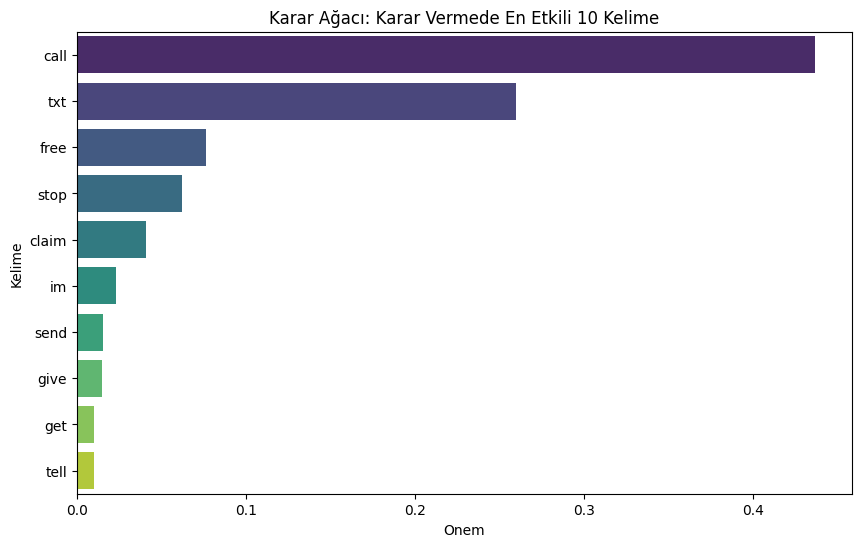

In [38]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

# Öznitelik önemlerini alalım
importances = dt_model.feature_importances_
feature_names = tfidf.get_feature_names_out() # Vektörleştirici ismine dikkat!

# Veriyi tablo haline getirelim
feature_importance_df = pd.DataFrame({'Kelime': feature_names, 'Onem': importances})
feature_importance_df = feature_importance_df.sort_values(by='Onem', ascending=False).head(10)

# Çizim
plt.figure(figsize=(10, 6))
sns.barplot(x='Onem', y='Kelime', data=feature_importance_df, palette='viridis')
plt.title('Karar Ağacı: Karar Vermede En Etkili 10 Kelime')
plt.show()

/tmp/ipykernel_2891/1537618850.py:30: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=metrics, y=values, palette=colors, ax=ax2)


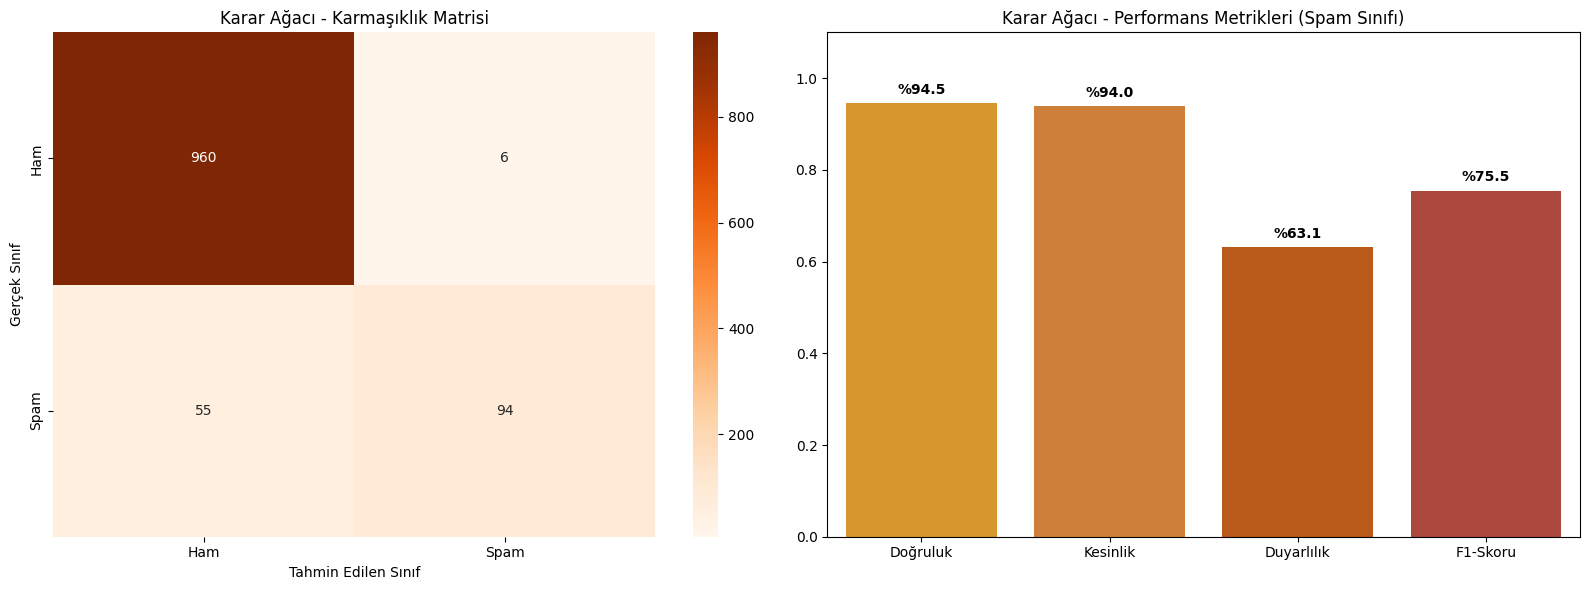

In [39]:
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import confusion_matrix, classification_report, accuracy_score, precision_score, recall_score, f1_score

# 1. Tahminleri alalım
y_pred_dt = dt_model.predict(X_test)

# 2. Metrikleri hesaplayalım (Spam sınıfı için)
accuracy = accuracy_score(y_test, y_pred_dt)
precision = precision_score(y_test, y_pred_dt)
recall = recall_score(y_test, y_pred_dt)
f1 = f1_score(y_test, y_pred_dt)

# 3. Görselleştirme (Yan yana iki grafik)
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(16, 6))

# --- SOL TARAF: Karmaşıklık Matrisi ---
cm = confusion_matrix(y_test, y_pred_dt)
sns.heatmap(cm, annot=True, fmt='d', cmap='Oranges', ax=ax1,
            xticklabels=['Ham', 'Spam'], yticklabels=['Ham', 'Spam'])
ax1.set_title('Karar Ağacı - Karmaşıklık Matrisi')
ax1.set_xlabel('Tahmin Edilen Sınıf')
ax1.set_ylabel('Gerçek Sınıf')

# --- SAĞ TARAF: Başarı Metrikleri ---
metrics = ['Doğruluk', 'Kesinlik', 'Duyarlılık', 'F1-Skoru']
values = [accuracy, precision, recall, f1]
colors = ['#f39c12', '#e67e22', '#d35400', '#c0392b']

sns.barplot(x=metrics, y=values, palette=colors, ax=ax2)
ax2.set_ylim(0, 1.1)
ax2.set_title('Karar Ağacı - Performans Metrikleri (Spam Sınıfı)')

# Çubukların üzerine değerleri yazdıralım
for i, v in enumerate(values):
    ax2.text(i, v + 0.02, f"%{v*100:.1f}", ha='center', fontweight='bold')

plt.tight_layout()
plt.show()

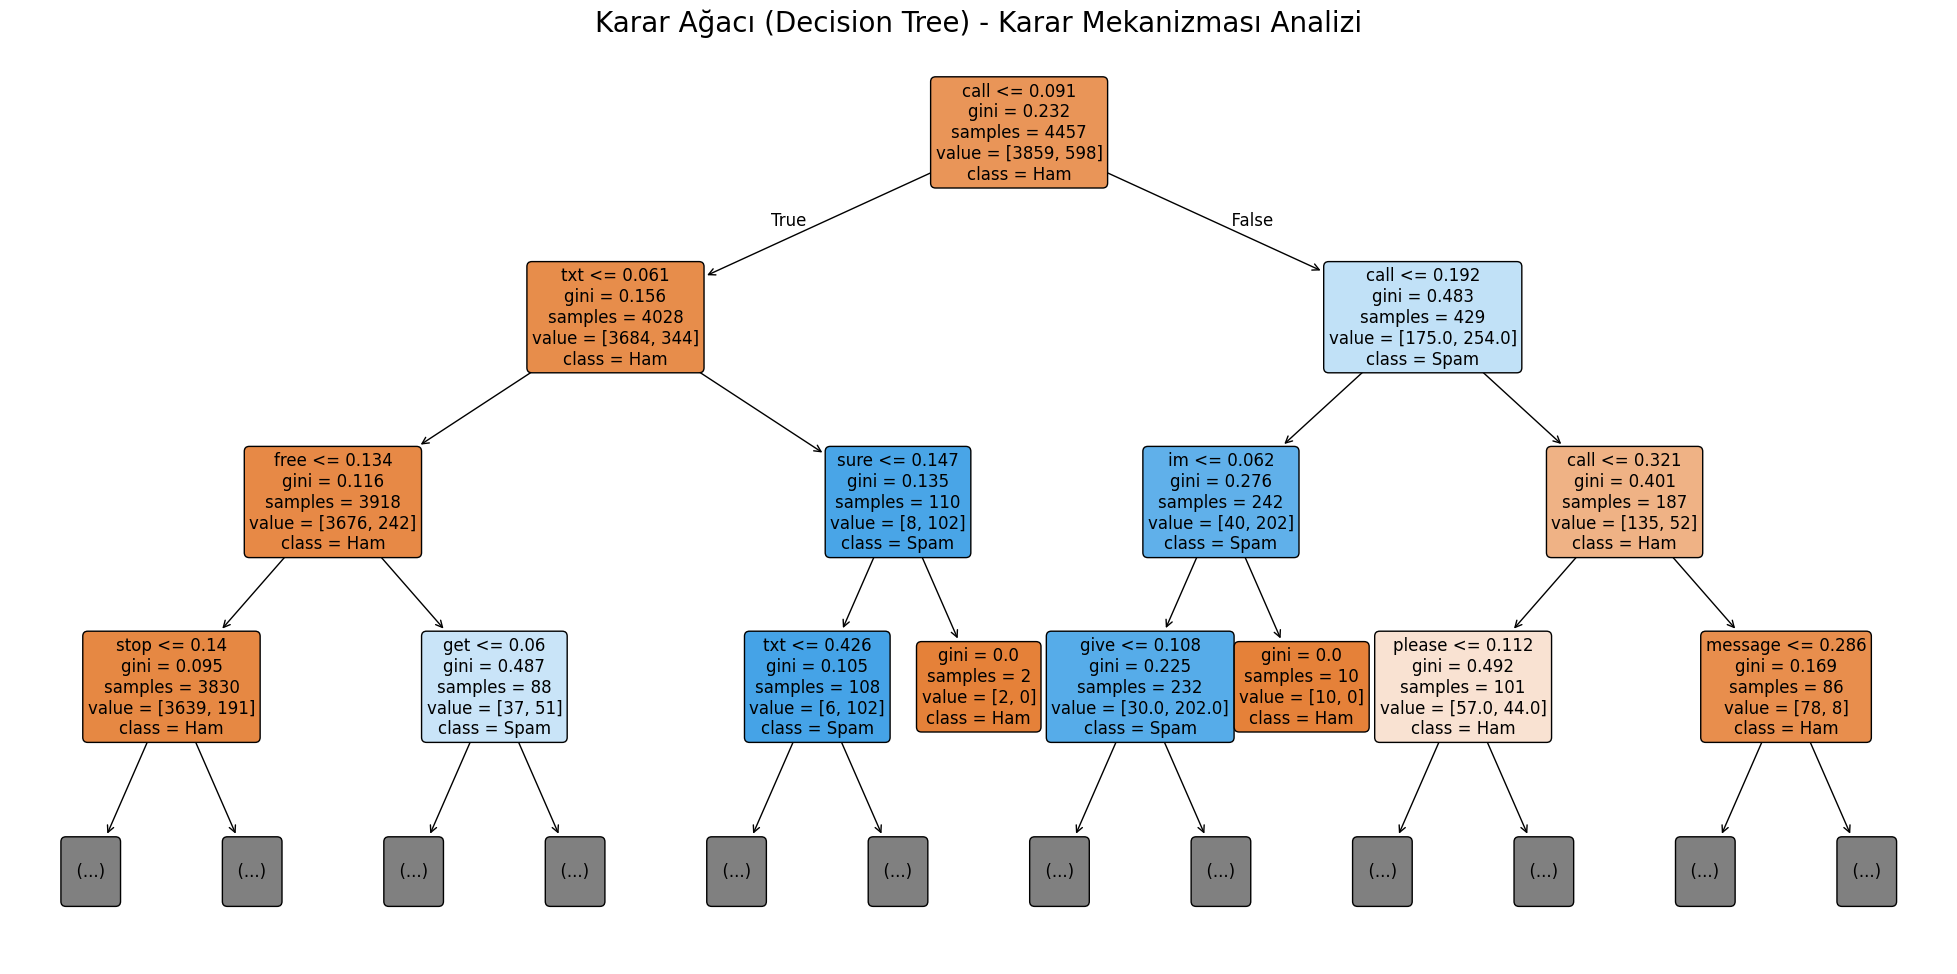

In [40]:
from sklearn import tree
import matplotlib.pyplot as plt

# 1. Görselin boyutunu ayarlıyoruz (Ağaç büyük olduğu için geniş bir alan lazım)
plt.figure(figsize=(25, 12))

# 2. Ağacı çizdiriyoruz
# feature_names: Kelime isimlerini (tfidf'den gelen) kutucuklara yazar.
# class_names: Karar sonucunu (Ham/Spam) belirtir.
# filled=True: Kutucukları başarıya göre renklendirir.
tree.plot_tree(dt_model,
               feature_names=tfidf.get_feature_names_out(),
               class_names=['Ham', 'Spam'],
               filled=True,
               rounded=True,
               fontsize=12,
               max_depth=3) # İlk 3 seviyeyi görmek yeterli, yoksa çok karışır.

plt.title("Karar Ağacı (Decision Tree) - Karar Mekanizması Analizi", fontsize=20)
plt.show()

RANDOM FOREST MODELİ

In [7]:
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score

# 1. Modeli oluştur
rf_model = RandomForestClassifier(n_estimators=100, random_state=42)

# 2. Modeli eğit
rf_model.fit(X_train, y_train)

# 3. Tahmin yap
y_pred_rf = rf_model.predict(X_test)

# 4. Sonuçları yazdır
print(f"Doğruluk: %{accuracy_score(y_test, y_pred_rf)*100:.2f}")

Doğruluk: %98.12


Random Forest Karmaşıklık Matrisi (Heatmap)

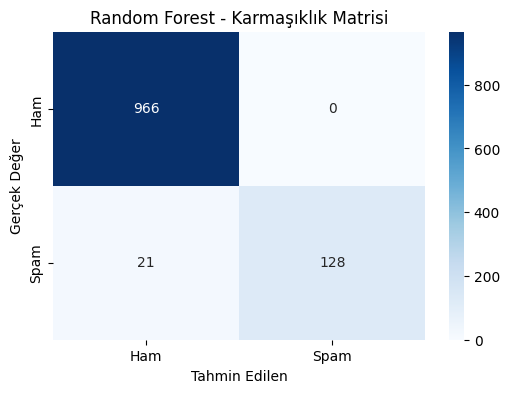

In [8]:
from sklearn.metrics import confusion_matrix
import seaborn as sns
import matplotlib.pyplot as plt

# rf_model ve y_pred_rf isimlerini yukarıdaki kodlarına göre kontrol et
cm_rf = confusion_matrix(y_test, y_pred_rf)

plt.figure(figsize=(6,4))
sns.heatmap(cm_rf, annot=True, fmt='d', cmap='Blues', xticklabels=['Ham', 'Spam'], yticklabels=['Ham', 'Spam'])
plt.xlabel('Tahmin Edilen')
plt.ylabel('Gerçek Değer')
plt.title('Random Forest - Karmaşıklık Matrisi')
plt.show()

Karar Ağacı Görselleştirme

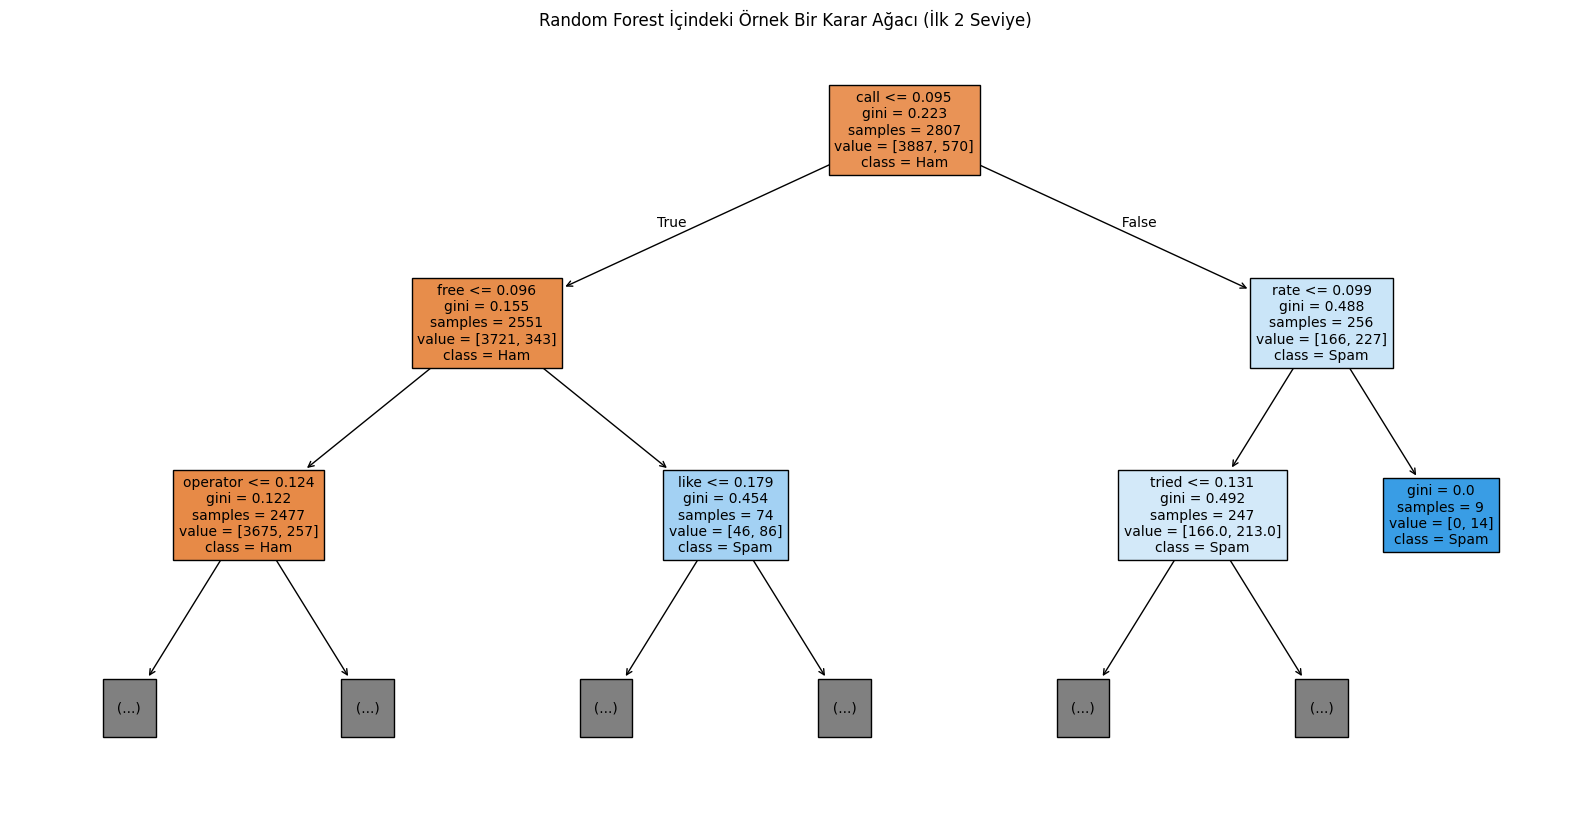

In [9]:
from sklearn.tree import plot_tree
import matplotlib.pyplot as plt

# Random Forest içindeki ilk ağacı (0. indeksteki) görselleştiriyoruz
plt.figure(figsize=(20,10))
plot_tree(rf_model.estimators_[0],
          feature_names=tfidf.get_feature_names_out(),
          class_names=['Ham', 'Spam'],
          filled=True,
          max_depth=2, # Çok karmaşık olmasın diye derinliği kısıtlıyoruz
          fontsize=10)

plt.title("Random Forest İçindeki Örnek Bir Karar Ağacı (İlk 2 Seviye)")
plt.show()

1. Karar Mekanizması ve Terimler:

Kök ve Karar Düğümleri (Üst Kutular): Ağacın en tepesinde yer alan call, free ve operator gibi terimler, veri setini en iyi ayıran anahtar kelimelerdir. Örneğin; call <= 0.095 ifadesi, ilgili mesajdaki "call" kelimesinin TF-IDF ağırlığının bu değerden küçük olup olmadığını sorgular.

Gini Katsayısı: Düğümün "saflık" derecesini gösterir. Gini değeri 0'a yaklaştıkça, o gruptaki mesajların neredeyse tamamı aynı sınıfa (sadece ham veya sadece spam) aittir.

Samples (Örnek Sayısı): İlgili karar aşamasında değerlendirilen toplam mesaj sayısını ifade eder.

Value (Sınıf Dağılımı): Kutunun içindeki mesajların sınıflara göre dağılımını gösterir (Örn: [Ham Sayısı, Spam Sayısı]).

2. Renklerin ve Kutuların Anlamı:

Turuncu Kutular: Bu düğümlerde "Ham" (normal) mesajların yoğunlukta olduğunu gösterir. Renk ne kadar koyulaşırsa, o düğümdeki mesajların saflığı (Ham olma oranı) o kadar artar.

Mavi Kutular: Bu düğümlerde "Spam" mesajların yoğunlukta olduğunu temsil eder. Koyu mavi kutular, modelin o noktada "Spam" kararı verdiğini kesinleştirir.

Gri Kutucuklar (Sessiz Düğümler): Bu kutular, ağacın görselleştirme sınırları (derinlik kısıtlaması) nedeniyle o noktada bitmediğini, dallanmanın aşağıya doğru devam ettiğini simgeler. Bu düğümler, henüz nihai bir sınıfa atanmamış, alt aşamalarda farklı kelime kriterlerine göre bölünmeye devam eden ara süreçleri temsil eder.

Performans Metrikleri Çubuk Grafiği

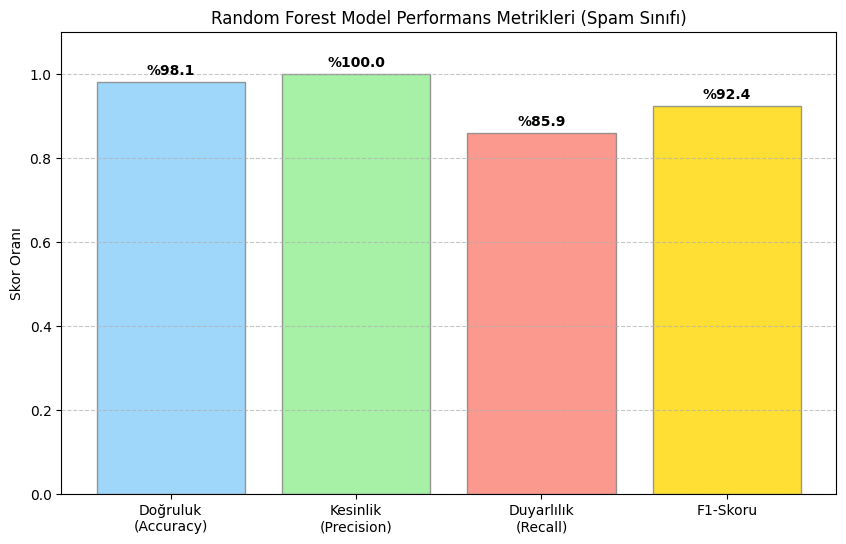

In [10]:
from sklearn.metrics import precision_recall_fscore_support, accuracy_score

# Metrikleri hesaplayalım (Spam sınıfı için)
acc_rf = accuracy_score(y_test, y_pred_rf)
prec_rf, rec_rf, f1_rf, _ = precision_recall_fscore_support(y_test, y_pred_rf, average='binary')

metrikler = ['Doğruluk\n(Accuracy)', 'Kesinlik\n(Precision)', 'Duyarlılık\n(Recall)', 'F1-Skoru']
skorlar = [acc_rf, prec_rf, rec_rf, f1_rf]
renkler = ['lightskyblue', 'lightgreen', 'salmon', 'gold']

# Grafik çizimi
plt.figure(figsize=(10, 6))
barlar = plt.bar(metrikler, skorlar, color=renkler, edgecolor='gray', alpha=0.8)

# Çubukların üzerine yüzde değerlerini yazalım
for bar in barlar:
    yval = bar.get_height()
    plt.text(bar.get_x() + bar.get_width()/2, yval + 0.01, f'%{yval*100:.1f}', ha='center', va='bottom', fontweight='bold')

plt.ylim(0, 1.1)
plt.ylabel('Skor Oranı')
plt.title('Random Forest Model Performans Metrikleri (Spam Sınıfı)')
plt.grid(axis='y', linestyle='--', alpha=0.7)

plt.show()

NAVİE BAYES **MODELİ**

In [11]:
from sklearn.naive_bayes import MultinomialNB
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix
# MultinomialNB():
# Naive Bayes'in "çok terimli" versiyonudur. TF-IDF gibi kelime sayımları ve ağırlıklarıyla çalışmak üzere tasarlanmıştır.
#  Naive Bayes modelini (Multinomial versiyonu) oluşturuyoruz
nb_model = MultinomialNB()

# Modeli eğitim verilerimizle eğitiyoruz(%80)
# X_train: (Kelime ağırlıkları), y_train: Ham/Spam (0/1)
nb_model.fit(X_train, y_train)

# Modeli teste sokuyoruz(%20 lik kısım)
y_pred = nb_model.predict(X_test)

# Başarıyı ölçüyoruz
print("--- Naive Bayes Performans Sonuçları ---")
# Modelin tahminleri (y_pred) ile gerçek cevapları (y_test) karşılaştırır.
print(f"Doğruluk (Accuracy) Skoru: %{accuracy_score(y_test, y_pred)*100:.2f}")
print("\nSınıflandırma Raporu:\n", classification_report(y_test, y_pred))

--- Naive Bayes Performans Sonuçları ---
Doğruluk (Accuracy) Skoru: %98.03

Sınıflandırma Raporu:
               precision    recall  f1-score   support

           0       0.98      1.00      0.99       966
           1       1.00      0.85      0.92       149

    accuracy                           0.98      1115
   macro avg       0.99      0.93      0.95      1115
weighted avg       0.98      0.98      0.98      1115



Naive Bayes Algoritması ile verisetinde duzenledigimiz her mesajdaki kelimelerin kelime ağırlıklarını bulmuştuk ve bayes bu spam mesajlarındaki geçen kelimelere bakarak bunların olasılıklarını hesaplar.Ve gelen yeni mesajın hesabını olasılık hesabı ile ham veya spamda geçme olasılıklarını çarpar.

**BAYES-Metriklerin Sütun Grafiği**

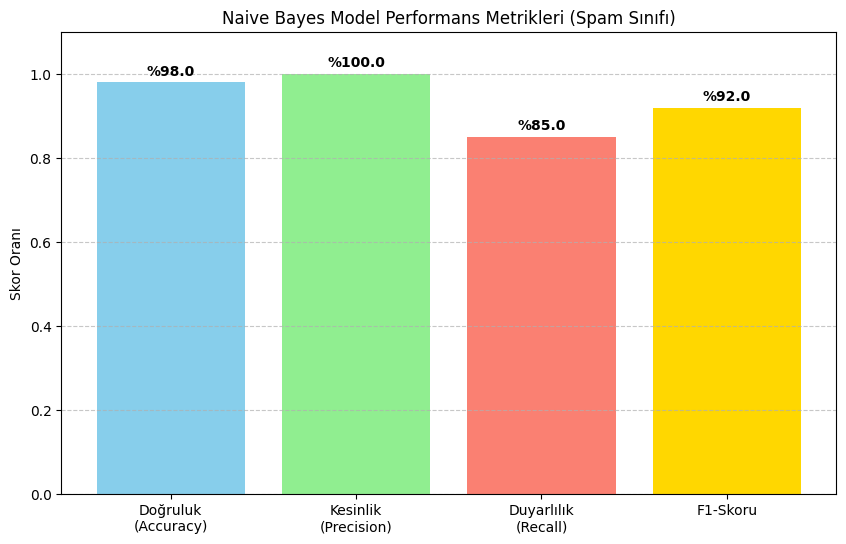

In [12]:
import matplotlib.pyplot as plt
import numpy as np

#  Metrik değerlerini bir listeye alıyoruz
metrik_isimleri = ['Doğruluk\n(Accuracy)', 'Kesinlik\n(Precision)', 'Duyarlılık\n(Recall)', 'F1-Skoru']
# Spam (1) sınıfına ait değerleri baz alıyoruz çünkü başarımızı o belirliyor
metrik_degerleri = [0.98, 1.00, 0.85, 0.92]

#  Grafik oluşturma
plt.figure(figsize=(10, 6))
renkler = ['skyblue', 'lightgreen', 'salmon', 'gold']
barlar = plt.bar(metrik_isimleri, metrik_degerleri, color=renkler)

#  Grafik üzerine değerleri (yüzdeleri) yazdıralım
for bar in barlar:
    yval = bar.get_height()
    plt.text(bar.get_x() + bar.get_width()/2, yval + 0.01, f'%{yval*100:.1f}', ha='center', va='bottom', fontweight='bold')

#  Grafik süslemeleri
plt.ylim(0, 1.1) # Üst sınırı biraz boş bırakalım ki sayılar görünsün
plt.ylabel('Skor Oranı')
plt.title('Naive Bayes Model Performans Metrikleri (Spam Sınıfı)')
plt.grid(axis='y', linestyle='--', alpha=0.7)

plt.show()

Doğruluk grafiği- %98 çıktı yüksek bir deger fakat veri setimiz dengesiz oldugu için diğer grafiklere ve F1-skoru grafiğine bakmamız önemli!!


# BAYES-Karmaşıklık Matrisi

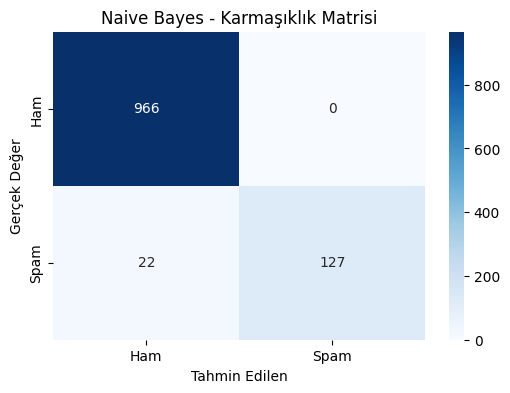

In [13]:
from sklearn.metrics import confusion_matrix
import seaborn as sns
import matplotlib.pyplot as plt

cm = confusion_matrix(y_test, y_pred)
plt.figure(figsize=(6,4))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', xticklabels=['Ham', 'Spam'], yticklabels=['Ham', 'Spam'])
plt.xlabel('Tahmin Edilen')
plt.ylabel('Gerçek Değer')
plt.title('Naive Bayes - Karmaşıklık Matrisi')
plt.show()

Sinir Ağları Modelini Eğitme ve Tahmin Yapma

In [14]:
from sklearn.neural_network import MLPClassifier
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix

# 1. Modeli oluşturuyoruz
# hidden_layer_sizes=(100,): Beynimizde 100 hücreli bir gizli katman var demek.
# max_iter=300: Modelin öğrenmek için veri üzerinden kaç kez geçeceğini belirler.
# random_state=42: Her çalıştırdığımızda aynı sonucu almamızı sağlar.
mlp_model = MLPClassifier(hidden_layer_sizes=(100,), max_iter=300, random_state=42)

# 2. Modeli eğitiyoruz (Öğrenme aşaması)
mlp_model.fit(X_train, y_train)

# 3. Test verisi ile tahmin yapıyoruz
y_pred_mlp = mlp_model.predict(X_test)

# 4. Genel başarıyı yazdıralım
print("--- Kübra'nın Sinir Ağları (MLP) Sonuçları ---")
print(f"Doğruluk (Accuracy): %{accuracy_score(y_test, y_pred_mlp)*100:.2f}")

--- Kübra'nın Sinir Ağları (MLP) Sonuçları ---
Doğruluk (Accuracy): %98.21


Sinir Ağları Karmaşıklık Matrisi (Heatmap)

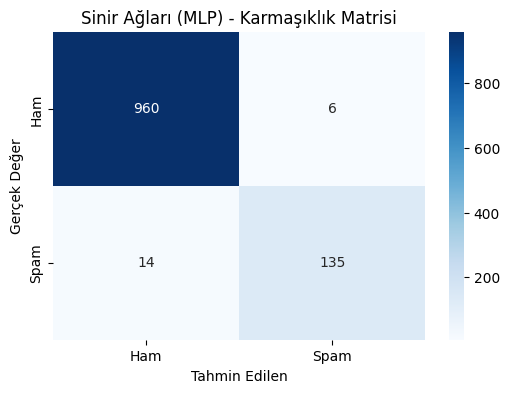

In [15]:
from sklearn.metrics import confusion_matrix
import seaborn as sns
import matplotlib.pyplot as plt

# mlp_model ve y_pred_mlp isimlerini kontrol et
cm_mlp = confusion_matrix(y_test, y_pred_mlp)

plt.figure(figsize=(6,4))
sns.heatmap(cm_mlp, annot=True, fmt='d', cmap='Blues', xticklabels=['Ham', 'Spam'], yticklabels=['Ham', 'Spam'])
plt.xlabel('Tahmin Edilen')
plt.ylabel('Gerçek Değer')
plt.title('Sinir Ağları (MLP) - Karmaşıklık Matrisi')
plt.show()

Sinir Ağları Performans Metrikleri Grafiği

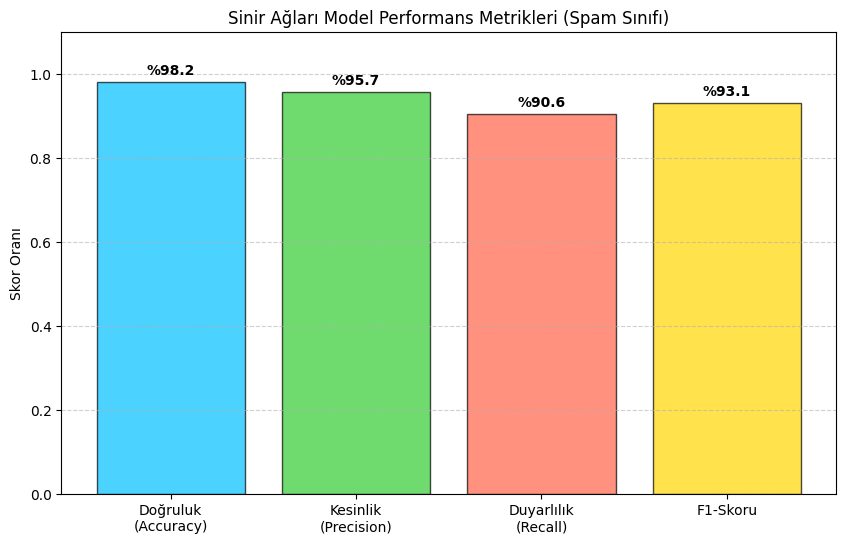

In [16]:
from sklearn.metrics import precision_recall_fscore_support, accuracy_score

# Metrikleri hesaplayalım (Spam sınıfı için)
acc_mlp = accuracy_score(y_test, y_pred_mlp)
prec_mlp, rec_mlp, f1_mlp, _ = precision_recall_fscore_support(y_test, y_pred_mlp, average='binary')

metrikler = ['Doğruluk\n(Accuracy)', 'Kesinlik\n(Precision)', 'Duyarlılık\n(Recall)', 'F1-Skoru']
skorlar = [acc_mlp, prec_mlp, rec_mlp, f1_mlp]
renkler = ['deepskyblue', 'limegreen', 'tomato', 'gold']

# Grafik çizimi
plt.figure(figsize=(10, 6))
barlar = plt.bar(metrikler, skorlar, color=renkler, edgecolor='black', alpha=0.7)

# Çubukların üzerine yüzde değerlerini yazalım
for bar in barlar:
    yval = bar.get_height()
    plt.text(bar.get_x() + bar.get_width()/2, yval + 0.01, f'%{yval*100:.1f}', ha='center', va='bottom', fontweight='bold')

plt.ylim(0, 1.1)
plt.ylabel('Skor Oranı')
plt.title('Sinir Ağları Model Performans Metrikleri (Spam Sınıfı)')
plt.grid(axis='y', linestyle='--', alpha=0.6)

plt.show()

Sinir Ağları (MLP) Loss Curve Grafiği

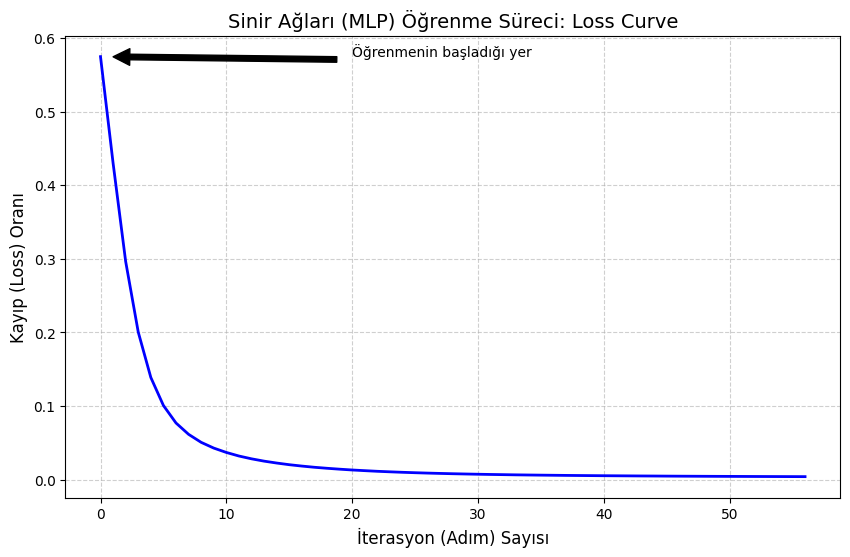

In [17]:
import matplotlib.pyplot as plt

#  Modeli eğitirken 'loss' değerlerini alıyoruz
# Not: MLPClassifier varsayılan olarak 'loss_curve_' özelliğine sahiptir.
kayip_degerleri = mlp_model.loss_curve_

# Görselleştirme
plt.figure(figsize=(10, 6))
plt.plot(kayip_degerleri, color='blue', linewidth=2)

plt.title('Sinir Ağları (MLP) Öğrenme Süreci: Loss Curve', fontsize=14)
plt.xlabel('İterasyon (Adım) Sayısı', fontsize=12)
plt.ylabel('Kayıp (Loss) Oranı', fontsize=12)
plt.grid(True, linestyle='--', alpha=0.6)

# Grafiğin üzerine küçük bir not ekleyelim
plt.annotate('Öğrenmenin başladığı yer', xy=(0, kayip_degerleri[0]),
             xytext=(20, kayip_degerleri[0]),
             arrowprops=dict(facecolor='black', shrink=0.05))

plt.show()

**Lojistik Regresyon**

In [18]:
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix

# Modeli oluşturuyoruz
# random_state=42: Deneyi her çalıştırdığımızda aynı katsayıları bulması için
log_model = LogisticRegression(random_state=42)

# Eğitim (Ağırlık/Katsayı Öğrenme)
# Model, X_train'deki 3000 kelime ağırlığına bakarak hangi kelimenin spama,
# hangisinin hama çektiğini (katsayıları) hesaplar.
log_model.fit(X_train, y_train)
#lojistik regresyonda ağırlıklar toplanır ve sigmoid fonksiyonuna sokulup 0-1 arasına sıkıştırılır.

# Hiç görmediği test verilerini (X_test) süzgecinden (Sigmoid) geçirir.
y_pred_log = log_model.predict(X_test)
# 0.5> Spam  , 0.5 'ten kucuk ise hham kabul edilir.

# Sonuçları Yazdırma
print("--- Lojistik Regresyon Performans Sonuçları ---")
print(f"Doğruluk (Accuracy) Skoru: %{accuracy_score(y_test, y_pred_log)*100:.2f}")
print("\nSınıflandırma Raporu:\n", classification_report(y_test, y_pred_log))

--- Lojistik Regresyon Performans Sonuçları ---
Doğruluk (Accuracy) Skoru: %96.50

Sınıflandırma Raporu:
               precision    recall  f1-score   support

           0       0.96      1.00      0.98       966
           1       0.99      0.74      0.85       149

    accuracy                           0.97      1115
   macro avg       0.98      0.87      0.92      1115
weighted avg       0.97      0.97      0.96      1115



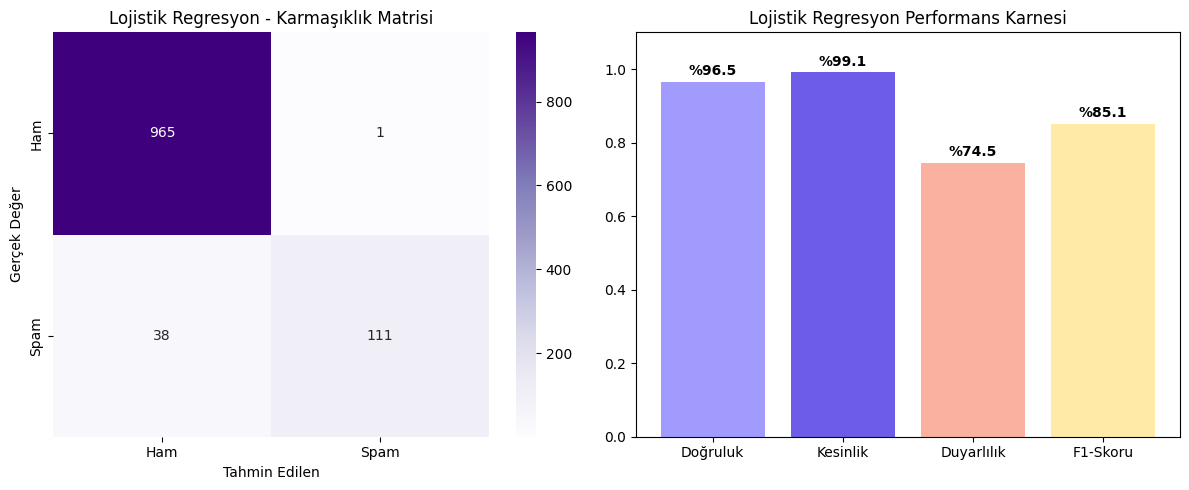

In [19]:
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import confusion_matrix, accuracy_score, precision_score, recall_score, f1_score

# --- GRAFİK 1: Karmaşıklık Matrisi (Confusion Matrix) ---
plt.figure(figsize=(12, 5))

# Sol tarafa Matrisi çizelim
plt.subplot(1, 2, 1)
cm_log = confusion_matrix(y_test, y_pred_log)
sns.heatmap(cm_log, annot=True, fmt='d', cmap='Purples', xticklabels=['Ham', 'Spam'], yticklabels=['Ham', 'Spam'])
plt.title('Lojistik Regresyon - Karmaşıklık Matrisi')
plt.xlabel('Tahmin Edilen')
plt.ylabel('Gerçek Değer')

# --- GRAFİK 2: Performans Metrikleri Sütun Grafiği ---
plt.subplot(1, 2, 2)
# Metrikleri hesaplayalım
acc = accuracy_score(y_test, y_pred_log)
pre = precision_score(y_test, y_pred_log)
rec = recall_score(y_test, y_pred_log)
f1 = f1_score(y_test, y_pred_log)

metrik_isimleri = ['Doğruluk', 'Kesinlik', 'Duyarlılık', 'F1-Skoru']
metrik_degerleri = [acc, pre, rec, f1]
renkler = ['#a29bfe', '#6c5ce7', '#fab1a0', '#ffeaa7']

barlar = plt.bar(metrik_isimleri, metrik_degerleri, color=renkler)
plt.ylim(0, 1.1)
plt.title('Lojistik Regresyon Performans Karnesi')

# Çubukların üzerine değerleri yazdıralım
for bar in barlar:
    yval = bar.get_height()
    plt.text(bar.get_x() + bar.get_width()/2, yval + 0.01, f'%{yval*100:.1f}', ha='center', va='bottom', fontweight='bold')

plt.tight_layout()
plt.show()

Optimum K Değerini Bulma Grafiği

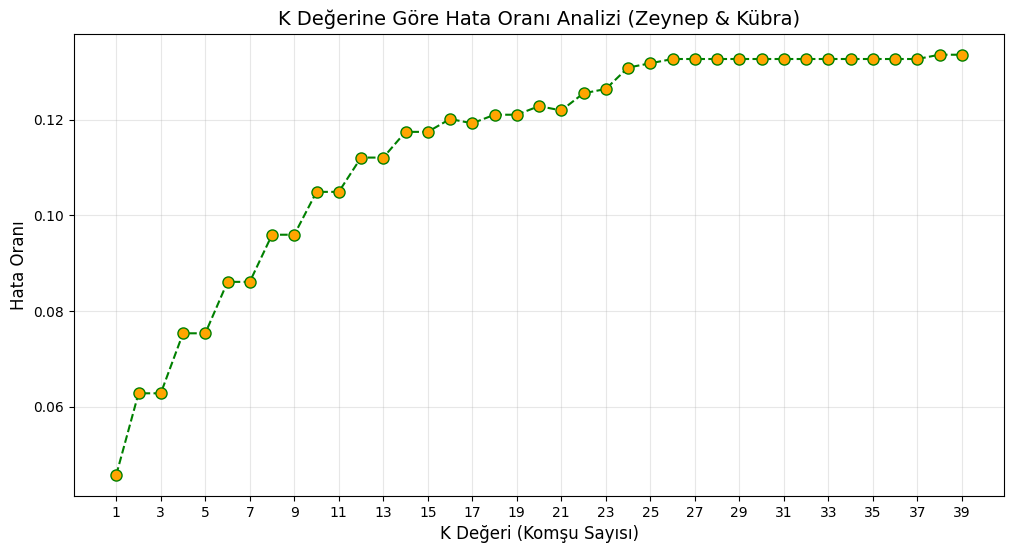

Grafiğe göre hata oranının en düşük olduğu optimum K değeri: 1


In [20]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.neighbors import KNeighborsClassifier

# 1. Farklı K değerleri için hata oranlarını hesaplayalım
hata_oranlari = []

# 1'den 40'a kadar K değerlerini test ediyoruz
for i in range(1, 40):
    knn_deneme = KNeighborsClassifier(n_neighbors=i, metric='euclidean')
    knn_deneme.fit(X_train, y_train)
    tahmin_i = knn_deneme.predict(X_test)
    # Gerçek değerle tahmin arasındaki farkın ortalamasını al (Hata oranı)
    hata_oranlari.append(np.mean(tahmin_i != y_test))

# 2. Görselleştirme
plt.figure(figsize=(12, 6))
plt.plot(range(1, 40), hata_oranlari, color='green', linestyle='dashed',
         marker='o', markerfacecolor='orange', markersize=8)

plt.title('K Değerine Göre Hata Oranı Analizi (Zeynep & Kübra)', fontsize=14)
plt.xlabel('K Değeri (Komşu Sayısı)', fontsize=12)
plt.ylabel('Hata Oranı', fontsize=12)
plt.xticks(range(1, 41, 2)) # X eksenini 2'şer 2'şer göster ki okunsun
plt.grid(True, alpha=0.3)
plt.show()

# En iyi K değerini yazdıralım
en_iyi_k = hata_oranlari.index(min(hata_oranlari)) + 1
print(f"Grafiğe göre hata oranının en düşük olduğu optimum K değeri: {en_iyi_k}")

KNN Modelini Eğitme ve Tahmin Yapma

In [21]:
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import accuracy_score, confusion_matrix

# n_neighbors=5: En yakın 5 komşuya bakarak karar ver demek.
# metric='euclidean': Aradaki mesafeyi kuş uçuşu (Öklid) olarak ölçer.
knn_model = KNeighborsClassifier(n_neighbors=5, metric='euclidean')

# 2. Modeli eğitiyoruz
knn_model.fit(X_train, y_train)

# 3. Test verisi ile tahmin yapıyoruz
y_pred_knn = knn_model.predict(X_test)

# 4. Genel başarıyı yazdıralım
print("En Yakın Komşu Sonuçları ---")
print(f"Doğruluk (Accuracy): %{accuracy_score(y_test, y_pred_knn)*100:.2f}")

En Yakın Komşu Sonuçları ---
Doğruluk (Accuracy): %92.47


KNN Karmaşıklık Matrisi (Heatmap)

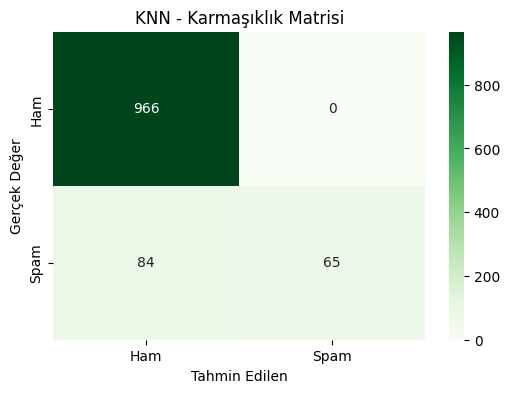

In [22]:
import seaborn as sns
import matplotlib.pyplot as plt

# Karmaşıklık matrisini hesapla
cm_knn = confusion_matrix(y_test, y_pred_knn)

# Görselleştirme
plt.figure(figsize=(6,4))
sns.heatmap(cm_knn, annot=True, fmt='d', cmap='Greens', # KNN için yeşil tonları
            xticklabels=['Ham', 'Spam'], yticklabels=['Ham', 'Spam'])
plt.xlabel('Tahmin Edilen')
plt.ylabel('Gerçek Değer')
plt.title('KNN - Karmaşıklık Matrisi')
plt.show()

KNN Başarı Metrikleri

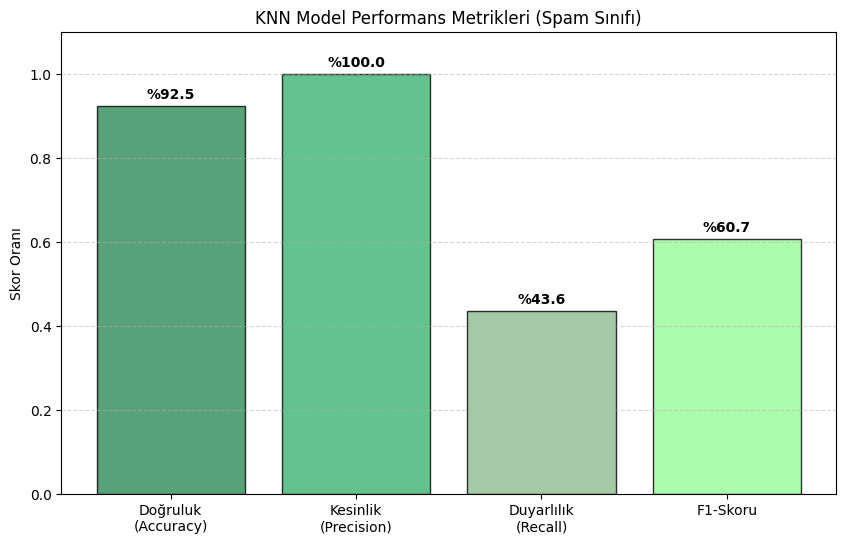

In [23]:
from sklearn.metrics import precision_recall_fscore_support

# Başarı oranlarını (Precision, Recall, F1) hesaplıyoruz
acc_knn = accuracy_score(y_test, y_pred_knn)
prec_knn, rec_knn, f1_knn, _ = precision_recall_fscore_support(y_test, y_pred_knn, average='binary')

metrikler = ['Doğruluk\n(Accuracy)', 'Kesinlik\n(Precision)', 'Duyarlılık\n(Recall)', 'F1-Skoru']
skorlar = [acc_knn, prec_knn, rec_knn, f1_knn]
renkler = ['#2e8b57', '#3cb371', '#8fbc8f', '#98fb98'] # Yeşil tonları

plt.figure(figsize=(10, 6))
barlar = plt.bar(metrikler, skorlar, color=renkler, edgecolor='black', alpha=0.8)

# Çubukların üzerine yüzde yazılarını ekle
for bar in barlar:
    yval = bar.get_height()
    plt.text(bar.get_x() + bar.get_width()/2, yval + 0.01, f'%{yval*100:.1f}',
             ha='center', va='bottom', fontweight='bold')

plt.ylim(0, 1.1)
plt.ylabel('Skor Oranı')
plt.title('KNN Model Performans Metrikleri (Spam Sınıfı)')
plt.grid(axis='y', linestyle='--', alpha=0.5)
plt.show()

# SVM C Parametresi **Analizi**

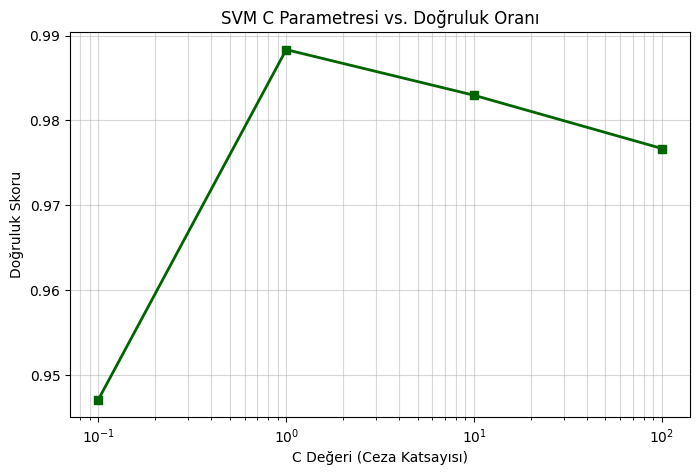

In [24]:
import matplotlib.pyplot as plt
from sklearn.svm import SVC

c_degerleri = [0.1, 1, 10, 100]
skorlar = []

for c in c_degerleri:
    gecici_svm = SVC(kernel='linear', C=c, random_state=42)
    gecici_svm.fit(X_train, y_train)
    skorlar.append(gecici_svm.score(X_test, y_test))

plt.figure(figsize=(8, 5))
plt.plot(c_degerleri, skorlar, marker='s', linestyle='-', color='darkgreen', linewidth=2)
plt.xscale('log') # C değerleri 10'un katları olduğu için logaritmik ölçek daha iyi görünür
plt.title('SVM C Parametresi vs. Doğruluk Oranı')
plt.xlabel('C Değeri (Ceza Katsayısı)')
plt.ylabel('Doğruluk Skoru')
plt.grid(True, which="both", ls="-", alpha=0.5)
plt.show()

SVM C parametresi bizim için modelin hata yapmaya ne kadar tahammül edeceğini belirler.

SVM sınır çizmeye çalışırken bazen zorlanır çünkü bazı spam ve ham mesajlar diğer tarafta gizlenmiş olabilir ve en optimum c parametresi için grafik çizdirdik.

-Düşük C parametresi: Bazı hatalı sınıfta yer alan mesajları görmezden gelip ve marjini en geniş seçer.Esnek bir sınır çizer

-Yüksek C Parametresi: Model eğitim verisindeki her bir noktayı doğru ayırmak için yolu(marjini) daraltır.Overfitting riski olur.Model hiç görmediği bir mesajta zorlanır.

# SVM **MODELİ**

In [25]:
from sklearn.svm import SVC
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix
import seaborn as sns
import matplotlib.pyplot as plt

# Modeli Tanımlama
# kernel='linear': Mesajları ayırmak için "doğrusal" bir sınır (çizgi) kullanacağımızı belirtiyoruz.
# C=1.0: "Ceza" parametresidir. Hatalara karşı ne kadar sert olacağımızı belirler.
svm_model = SVC(kernel='linear', random_state=42)

#  Eğitim (Destek Vektörlerini Bulma)
# Model, X_train içindeki en kritik "uç" mesajları seçer ve aralarından en geniş yolu açar.
svm_model.fit(X_train, y_train)

# Tahmin
# Test setindeki mesajların o yolun hangi tarafında kaldığına bakar.
y_pred_svm = svm_model.predict(X_test)

#Roc grafiğini çizdirmek için olasılık hesaplama:
svm_model = SVC(kernel='linear', probability=True, random_state=42)

# Başarı Sonuçları
print("--- SVM Performans Sonuçları ---")
print(f"Doğruluk (Accuracy) Skoru: %{accuracy_score(y_test, y_pred_svm)*100:.2f}")
print("\nSınıflandırma Raporu:\n", classification_report(y_test, y_pred_svm))

--- SVM Performans Sonuçları ---
Doğruluk (Accuracy) Skoru: %98.83

Sınıflandırma Raporu:
               precision    recall  f1-score   support

           0       0.99      1.00      0.99       966
           1       0.99      0.92      0.95       149

    accuracy                           0.99      1115
   macro avg       0.99      0.96      0.97      1115
weighted avg       0.99      0.99      0.99      1115



-Model,her bir mesajı TF-IDF ağırlıklarına göre bir koordinat sistemine yerleştirir.
-Spam ve ham mesajlar ağırlıklarına göre belli bölgelerde kümelenir.
-Svm bütün mesajlara değil, sınırdaki iki ham ve spam mesaja bakar(destek vektörleri)
-Model bu baktığı iki sınır mesajın arasına bir karar sınırı çizer.
Her 2 mesaja olan mesafe en yüksek seviyede(marjin) yani her iki mesajda eşit uzaklıkta olur.Objektif davranabilir.
-Yeni mesaj geldiğinde,mesajın kelime ağırlıkları denkleme koyulur ve çizilen sınırın hangi tarafında kalındığına bakar.

# SVM Başarı **Metrikleri**

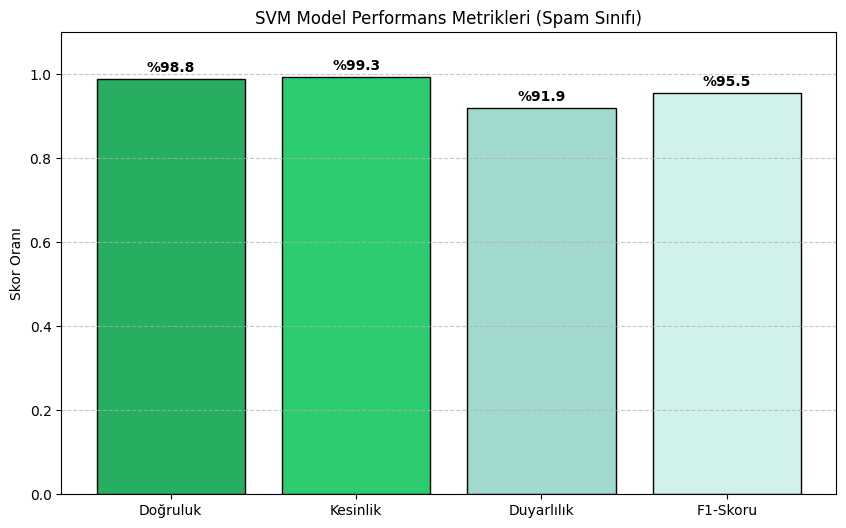

In [26]:
import matplotlib.pyplot as plt
import numpy as np
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score

# Metrikleri hesaplayalım
acc_svm = accuracy_score(y_test, y_pred_svm)
pre_svm = precision_score(y_test, y_pred_svm)
rec_svm = recall_score(y_test, y_pred_svm)
f1_svm = f1_score(y_test, y_pred_svm)

metrik_isimleri = ['Doğruluk', 'Kesinlik', 'Duyarlılık', 'F1-Skoru']
metrik_degerleri = [acc_svm, pre_svm, rec_svm, f1_svm]

plt.figure(figsize=(10, 6))
renkler = ['#27ae60', '#2ecc71', '#a2d9ce', '#d1f2eb'] # SVM için Yeşil tonları
barlar = plt.bar(metrik_isimleri, metrik_degerleri, color=renkler, edgecolor='black')

# Değerleri barların üzerine yazalım
for bar in barlar:
    yval = bar.get_height()
    plt.text(bar.get_x() + bar.get_width()/2, yval + 0.01, f'%{yval*100:.1f}', ha='center', va='bottom', fontweight='bold')

plt.ylim(0, 1.1)
plt.ylabel('Skor Oranı')
plt.title('SVM Model Performans Metrikleri (Spam Sınıfı)')
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.show()

# Karmaşıklık Matrisi ve **Karşılaştırma**

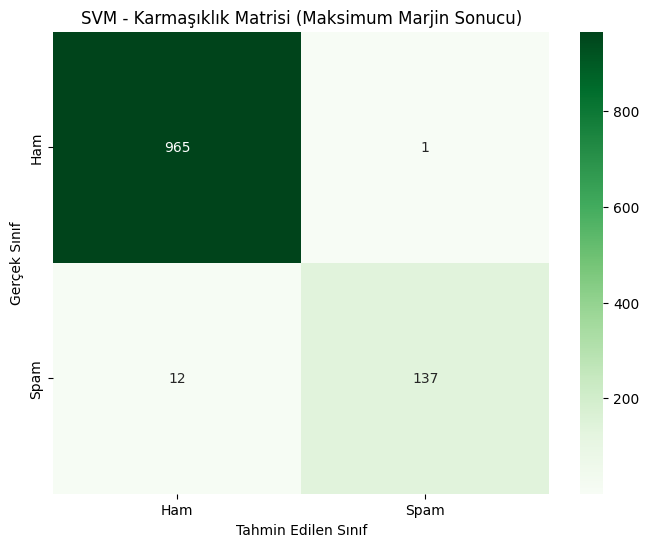

In [27]:
# --- SVM Karmaşıklık Matrisi Grafiği ---
plt.figure(figsize=(8, 6))
cm_svm = confusion_matrix(y_test, y_pred_svm)

sns.heatmap(cm_svm, annot=True, fmt='d', cmap='Greens',
            xticklabels=['Ham', 'Spam'], yticklabels=['Ham', 'Spam'])

plt.title('SVM - Karmaşıklık Matrisi (Maksimum Marjin Sonucu)')
plt.xlabel('Tahmin Edilen Sınıf')
plt.ylabel('Gerçek Sınıf')
plt.show()

XGBoost Modelini Eğitme ve Tahmin Yapma

In [28]:
from xgboost import XGBClassifier
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report
import seaborn as sns
import matplotlib.pyplot as plt

# 1. Modeli tanımlıyoruz
# n_estimators: Kaç tane ağaç kurulacağı (hataları düzelte düzelte gider)
# learning_rate: Öğrenme hızı (0.1 idealdir, modeli yavaş ama sağlam eğitir)
xgb_model = XGBClassifier(n_estimators=100, learning_rate=0.1, max_depth=5, random_state=42)

# 2. Modeli eğitiyoruz
xgb_model.fit(X_train, y_train)

# 3. Test verisi ile tahmin yapıyoruz
y_pred_xgb = xgb_model.predict(X_test)

# 4. Genel başarıyı yazdıralım
print("--- XGBoost Sonuçları ---")
print(f"Doğruluk (Accuracy): %{accuracy_score(y_test, y_pred_xgb)*100:.2f}")

--- XGBoost Sonuçları ---
Doğruluk (Accuracy): %97.13


XGBoost Karmaşıklık Matrisi (Heatmap)

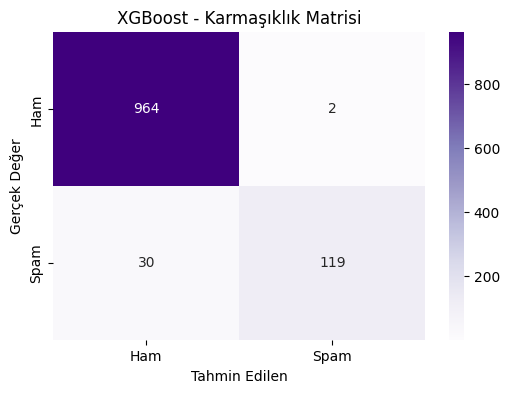

In [29]:
# Karmaşıklık matrisini hesapla
cm_xgb = confusion_matrix(y_test, y_pred_xgb)

# Görselleştirme
plt.figure(figsize=(6,4))
sns.heatmap(cm_xgb, annot=True, fmt='d', cmap='Purples', # XGBoost için mor tonları seçtim
            xticklabels=['Ham', 'Spam'], yticklabels=['Ham', 'Spam'])
plt.xlabel('Tahmin Edilen')
plt.ylabel('Gerçek Değer')
plt.title('XGBoost - Karmaşıklık Matrisi')
plt.show()

Öznitelik Önem Düzeyi Grafiği

/tmp/ipykernel_2891/1046322212.py:13: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x='Önem', y='Kelime', data=feature_importance_df, palette='viridis')


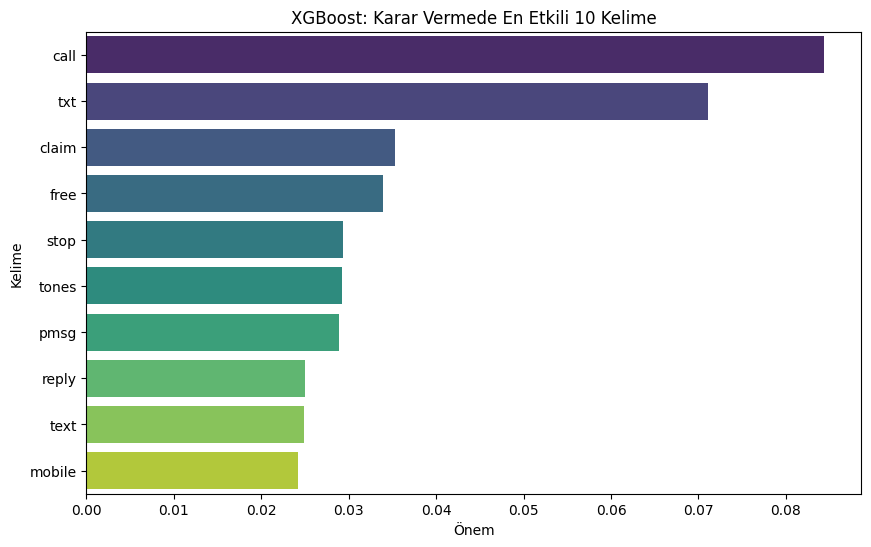

In [30]:
# En önemli 10 kelimeyi çekelim
import pandas as pd

importances = xgb_model.feature_importances_
feature_names = tfidf.get_feature_names_out() # TF-IDF'ten kelime isimlerini alıyoruz

# Veriyi tablo haline getirip en iyileri seçelim
feature_importance_df = pd.DataFrame({'Kelime': feature_names, 'Önem': importances})
feature_importance_df = feature_importance_df.sort_values(by='Önem', ascending=False).head(10)

# Grafiğe dökelim
plt.figure(figsize=(10,6))
sns.barplot(x='Önem', y='Kelime', data=feature_importance_df, palette='viridis')
plt.title('XGBoost: Karar Vermede En Etkili 10 Kelime')
plt.show()

Tüm Modellerin Karşılaştırma Tablosu

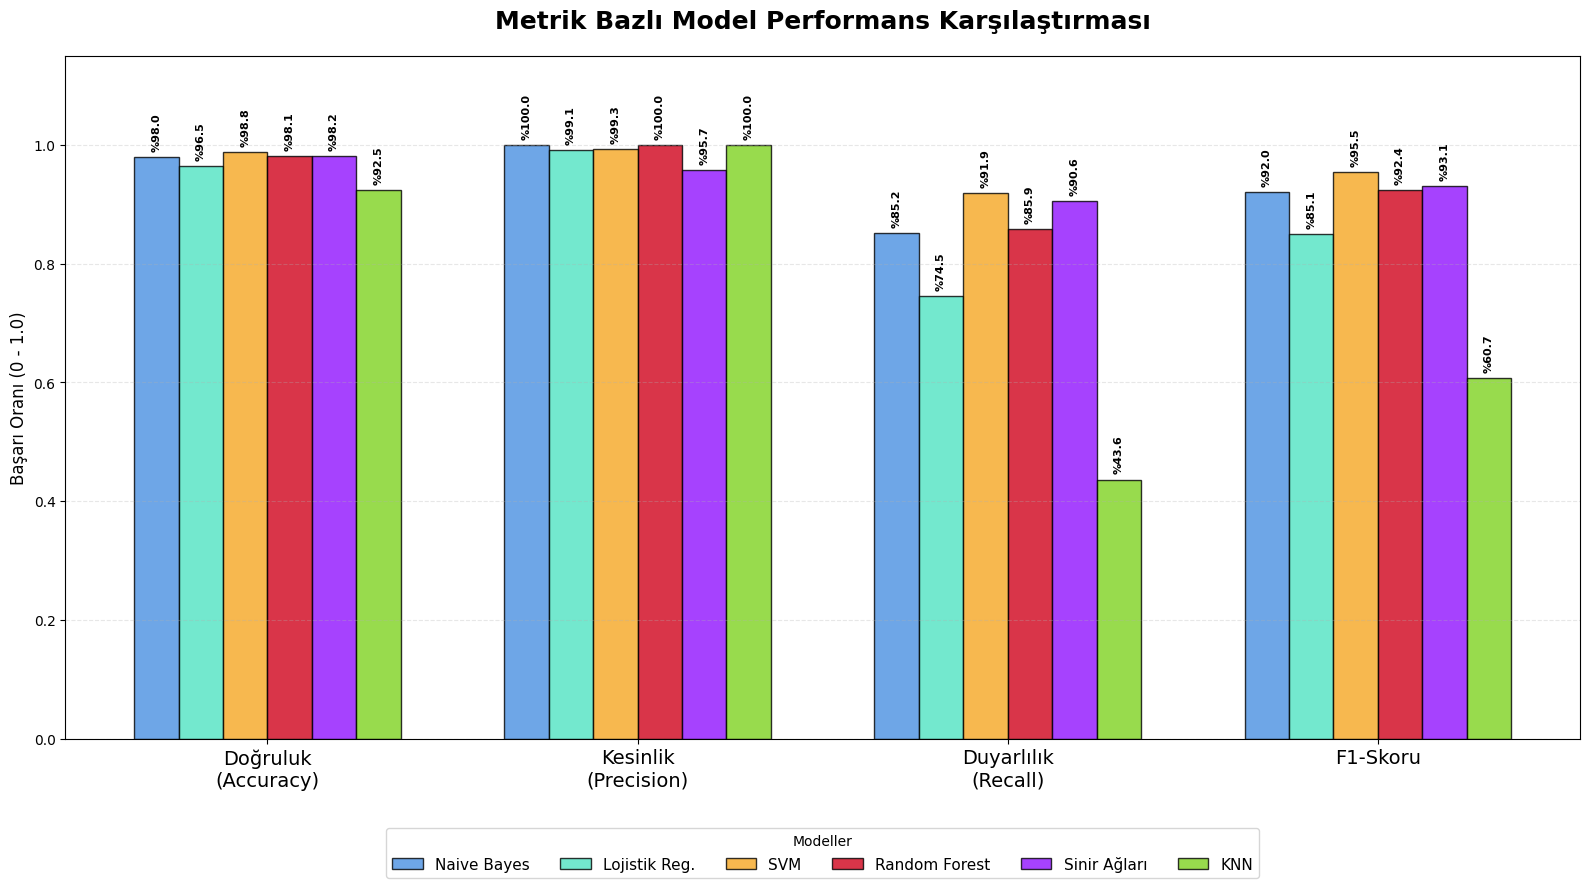

In [31]:
import matplotlib.pyplot as plt
import numpy as np
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score

# verileri hazırlama
metrikler = ['Doğruluk\n(Accuracy)', 'Kesinlik\n(Precision)', 'Duyarlılık\n(Recall)', 'F1-Skoru']
modeller = ['Naive Bayes', 'Lojistik Reg.', 'SVM', 'Random Forest', 'Sinir Ağları', 'KNN']

try:

    tahminler = [y_pred, y_pred_log, y_pred_svm, y_pred_rf, y_pred_mlp, y_pred_knn]

    # Her model için metrikleri hesaplıyoruz
    # Model bazlı değil, metrik bazlı gruplama yapacağız
    data = []
    for p in tahminler:
        data.append([
            accuracy_score(y_test, p),
            precision_score(y_test, p),
            recall_score(y_test, p),
            f1_score(y_test, p)
        ])

    # graiği çizme
    x = np.arange(len(metrikler))  # X ekseninde 4 metrik olacak
    width = 0.12  # Sütun genişliği (6 model sığması için daralttık)

    plt.figure(figsize=(16, 9))

    # Her model için ayrı bir bar seti çiziyoruz
    colors = ['#4A90E2', '#50E3C2', '#F5A623', '#D0021B', '#9013FE', '#7ED321']

    for i in range(len(modeller)):
        # i. modelin 4 metrikteki değerlerini çiz
        model_degerleri = data[i]
        plt.bar(x + (i - 2.5) * width, model_degerleri, width, label=modeller[i], color=colors[i], edgecolor='black', alpha=0.8)

        # Değerleri sütunların üzerine yazalım
        for j in range(len(metrikler)):
            plt.text(x[j] + (i - 2.5) * width, model_degerleri[j] + 0.01, f'%{model_degerleri[j]*100:.1f}',
                     ha='center', va='bottom', rotation=90, fontsize=8, fontweight='bold')


    plt.title('Metrik Bazlı Model Performans Karşılaştırması', fontsize=18, pad=20, fontweight='bold')
    plt.xticks(x, metrikler, fontsize=14)
    plt.ylabel('Başarı Oranı (0 - 1.0)', fontsize=12)
    plt.ylim(0, 1.15)
    plt.legend(title="Modeller", loc='upper center', bbox_to_anchor=(0.5, -0.12), ncol=6, fontsize=11)
    plt.grid(axis='y', linestyle='--', alpha=0.3)

    plt.tight_layout()
    plt.show()

except NameError as e:
    print(f"HATA: {e} değişkeni bulunamadı. Lütfen 'Çalışma Zamanı -> Tümünü Çalıştır' yaparak hafızayı tazeleyin.")

Canlı Test (Gözlem) Kodu

In [32]:


def spam_mi_degil_mi(yeni_mesaj):
    try:

        sayisal_mesaj = tfidf.transform([yeni_mesaj])

        # En güçlü modelin olan Sinir Ağları (mlp_model) ile tahmin yapalım
        tahmin = mlp_model.predict(sayisal_mesaj)

        if tahmin[0] == 1:
            return " DİKKAT: BU BİR SPAM MESAJDIR!"
        else:
            return "GÜVENLİ: BU NORMAL BİR MESAJDIR."

    except NameError as e:
        return f"HATA: {e} değişkeni bulunamadı. Lütfen yukarıdaki TF-IDF ve Model hücrelerini çalıştır."

# --- DENEYELİM ---
mesaj1 = "Congratulations! You won a free iPhone 15. Call now!"
print(f"Mesaj 1: {mesaj1}")
print(f"Sonuç: {spam_mi_degil_mi(mesaj1)}")

print("-" * 40)

mesaj2 = "Hi Zeynep, are we still going to the library tomorrow?"
print(f"Mesaj 2: {mesaj2}")
print(f"Sonuç: {spam_mi_degil_mi(mesaj2)}")

Mesaj 1: Congratulations! You won a free iPhone 15. Call now!
Sonuç:  DİKKAT: BU BİR SPAM MESAJDIR!
----------------------------------------
Mesaj 2: Hi Zeynep, are we still going to the library tomorrow?
Sonuç: GÜVENLİ: BU NORMAL BİR MESAJDIR.


Hibrit Model Yaklaşımı: Çoklu Algoritma Oy Birliği (Voting Classifier) ile Karar Mekanizması

In [33]:
from sklearn.ensemble import VotingClassifier
from sklearn.metrics import accuracy_score, classification_report



try:

    modeller_konseyi = [
        ('naive_bayes', nb_model),
        ('log_reg', log_model),
        ('svm', svm_model),
        ('random_forest', rf_model),
        ('neural_net', mlp_model),
        ('knn', knn_model)
    ]

    # Oy Birliği Sınıflandırıcısı (Hard Voting)
    hibrit_model = VotingClassifier(estimators=modeller_konseyi, voting='hard')

    #  Eğitim
    hibrit_model.fit(X_train, y_train)

    #  Tahmin
    y_pred_hibrit = hibrit_model.predict(X_test)

    # --- SONUÇLAR ---
    print("\n" + "="*50)
    print("   HİBRİT MODEL (6 MODEL ORTAK KARARI) SONUÇLARI   ")
    print("="*50)

    dogruluk = accuracy_score(y_test, y_pred_hibrit)
    print(f"Hibrit Model Başarı Oranı: %{dogruluk*100:.2f}")

    print("\nDetaylı Sınıflandırma Raporu:")
    print(classification_report(y_test, y_pred_hibrit, target_names=['Ham', 'Spam']))

except NameError as e:
    print(f"HATA: {e} değişkeni bulunamadı!")
    print("ÇÖZÜM: Lütfen yukarıdaki tüm modellerin hücrelerini sırayla çalıştırın. Özellikle hata veren modeli bulun.")


   HİBRİT MODEL (6 MODEL ORTAK KARARI) SONUÇLARI   
Hibrit Model Başarı Oranı: %97.67

Detaylı Sınıflandırma Raporu:
              precision    recall  f1-score   support

         Ham       0.97      1.00      0.99       966
        Spam       1.00      0.83      0.90       149

    accuracy                           0.98      1115
   macro avg       0.99      0.91      0.95      1115
weighted avg       0.98      0.98      0.98      1115



ROC eğrisi çizdirmek için modelin olasılık skorlarına ihtiyacımız vardı. Scikit-learn kütüphanesinde SVM varsayılan olarak bu skorları üretmez. probability=True parametresini eklediğimizde model yapısı değiştiği için onu tekrar fit (eğitme) işlemine sokmamız gerekti."

In [34]:
# 1. Önce modeli olasılık üretecek şekilde GÜNCELLEYİP tanımlıyoruz
svm_model = SVC(kernel='linear', probability=True, random_state=42)

# 2. ŞİMDİ EĞİTİYORUZ (Hata almamak için bu satır ŞART)
svm_model.fit(X_train, y_train)

# 3. ŞİMDİ ROC kodunu tekrar çalıştırabilirsin, hata vermeyecektir.

SVC(kernel='linear', probability=True, random_state=42)

# Tüm Modeller için ROC **Grafiği**

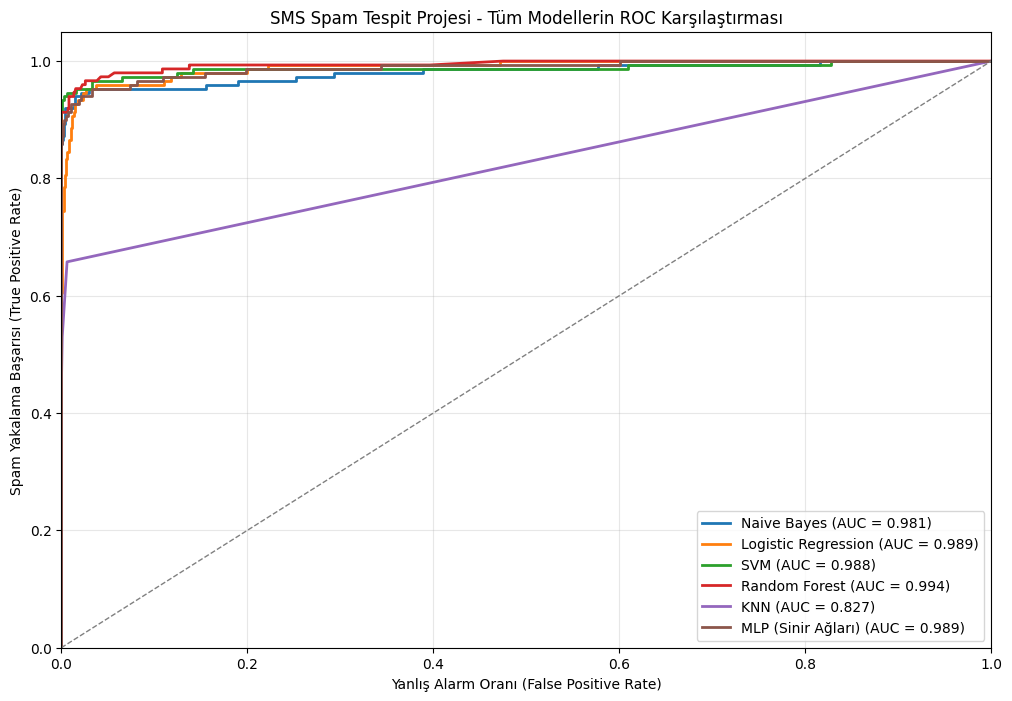

In [35]:
from sklearn.metrics import roc_curve, auc
import matplotlib.pyplot as plt

# 1. Her modelin "Spam olma olasılığını" (Probability) alıyoruz
# predict_proba'nın 1. indeksi [:, 1] bize spam olma ihtimalini verir.
probs_dict = {
    'Naive Bayes': nb_model.predict_proba(X_test)[:, 1],
    'Logistic Regression': log_model.predict_proba(X_test)[:, 1],
    'SVM': svm_model.predict_proba(X_test)[:, 1],
    'Random Forest': rf_model.predict_proba(X_test)[:, 1],
    'KNN': knn_model.predict_proba(X_test)[:, 1],
    'MLP (Sinir Ağları)': mlp_model.predict_proba(X_test)[:, 1]
}

plt.figure(figsize=(12, 8))

# 2. Her model için döngüyle ROC hesaplayıp çizdirelim
# Bu kısım her model için farklı eşik değerleri (thresholds) deneyecek
for name, probs in probs_dict.items():
    fpr, tpr, _ = roc_curve(y_test, probs)
    area = auc(fpr, tpr) # AUC (Alan) hesaplıyoruz
    plt.plot(fpr, tpr, lw=2, label=f'{name} (AUC = {area:.3f})')

# 3. Şans Çizgisi (Yazı-tura atan model çizgisi)
plt.plot([0, 1], [0, 1], color='gray', lw=1, linestyle='--')

# 4. Grafik Süslemeleri
plt.xlim([0.0, 1.0])
plt.ylim([0.0, 1.05])
plt.xlabel('Yanlış Alarm Oranı (False Positive Rate)')
plt.ylabel('Spam Yakalama Başarısı (True Positive Rate)')
plt.title('SMS Spam Tespit Projesi - Tüm Modellerin ROC Karşılaştırması')
plt.legend(loc="lower right")
plt.grid(alpha=0.3)
plt.show()

"Şekil X’de sunulan ROC Eğrisi karşılaştırması sonucunda, çalışılan 6 farklı algoritma arasında en yüksek ayırt edicilik performansını 0.994 AUC değeri ile Random Forest modeli sergilemiştir. Bunu sırasıyla Logistic Regression (%98.9) ve MLP (%98.9) takip etmektedir. Grafiksel analizde, modellerin büyük çoğunluğunun sol üst köşeye (ideal nokta) oldukça yakın seyretmesi, kurulan spam tespit sisteminin genelleme yeteneğinin yüksek olduğunu göstermektedir. KNN modelinin ise 0.827 AUC değeri ile diğer modellerin gerisinde kaldığı gözlemlenmiştir. Bu durum, yüksek boyutlu metin verilerinde olasılıksal ve topluluk (ensemble) öğrenme yöntemlerinin daha kararlı sonuçlar verdiğini doğrulamaktadır."

*Accuracy sadece %50 eşik değerindeki tek bir başarıyı ölçer. ROC-AUC ise modelin her türlü eşik değerindeki genel ayırma kapasitesini ölçer. Random Forest, genel potansiyel olarak spamleri ayırmada en geniş güvenlik marjını sunan modelimiz olmuştur."*